In [26]:
import pandas as pd
import sys
sys.path.append("./../src")
import utils
from setfit import SetFitModel
import ollama
from rouge_score import rouge_scorer
import requests
import json
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
from datasets import load_dataset
from StanceDetector import StanceDetector
import utils

random_seed=41


In [2]:
#Download the dataset from huggingface
dataset1 = load_dataset("andreacristiano/uk_parliament")
df1 = dataset1['train'].to_pandas()

In [3]:
# read records from json file
with open('./../data/external/records.json', 'r') as f:
    records = json.load(f) 


In [4]:
def politician_stance(summarizations, name):
    summary = summarizations[summarizations['speaker'] == name]['summary']
    if not summary.empty:
        return summary.iloc[0]
    else:
        return f"No summary found for {name}."

## Nuclear energy

In [27]:
# FOR DEBUGGING PURPOSES, TO RELOAD THE MODULE WITHOUT RESTARTING THE KERNEL

import importlib
import StanceDetector as sd_module

def reload_detector():
    importlib.reload(sd_module)
    return sd_module.StanceDetector

In [28]:
topic = "nuclear"

# DEBUG----------
StanceDetector = reload_detector()
# ------------------
uk=StanceDetector(df1, records, random_seed=random_seed)

c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [9]:
filtered_df= uk.filter_speeches(topic, years=[2011, 2012, 2013, 2014]) # years=[2011, 2012, 2013, 2014]

classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

Filtering speeches for topic: nuclear
Number of speeches after filtering for topic 'nuclear' in years [2011, 2012, 2013, 2014]: 597
Classifying filtered speeches for topic: nuclear
"Number of opinionated speeches for nuclear: 43
Summarization completed for topic: nuclear


In [10]:
summarizations

,summary,party,speaker
0,The politician opposes the development of nucl...,Con,David Cameron
1,The politician believes nuclear energy should ...,Lab,Paul Flynn
2,The politician opposes the use of nuclear ener...,Con,Tony Baldry
3,The politician believes nuclear energy should ...,LibDem,Christopher Huhne
4,The politician opposes the development of new ...,LibDem,Martin Horwood
5,The politician opposes nuclear energy due to c...,GPEW,Caroline Lucas
6,The politician expresses concerns regarding th...,Con,Mike Weatherley
7,The politician opposes measures that could res...,Lab,Alan Whitehead
8,The politician opposes the use of nuclear ener...,Lab,Jeremy Corbyn
9,The politician opposes the expansion of nuclea...,Con,Charles Hendry


Note: Per questioni di mantenimento probabilmente sarebbe meglio salvare le summarization su file esterno e non all'interno della variabile. Altrimenti ogni volta dobbiamo runnare tutto da capo.

In [11]:
# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

In [7]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')

# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)
# -----------------

In [43]:
anchors=uk.generate_anchors("nuclear")

Generating stance anchors for topic: nuclear


In [44]:
anchors

[{'topic': 'The safety and reliability of nuclear energy production are central concerns.',
  'pro': 'Significant safety concerns, including the Fukushima disaster and cost overruns, necessitate a cautious approach to nuclear energy development.',
  'con': 'The pursuit of nuclear energy should proceed, acknowledging the need for reliable power generation despite inherent risks.'},
 {'topic': 'The financial implications of nuclear energy – particularly waste management – represent a key point of contention.',
  'pro': 'The unresolved issues of decommissioning and radioactive waste disposal pose substantial and unaddressed financial challenges for nuclear energy.',
  'con': 'Concerns regarding the significant and unaddressed costs of decommissioning and nuclear waste disposal are a primary reason to oppose nuclear energy.'},
 {'topic': 'Public confidence and acceptance of nuclear energy are subject to considerable debate.',
  'pro': 'Declining public confidence, influenced by safety conc

Computing UMAP embeddings for topic: nuclear


Batches: 100%|██████████| 1/1 [00:02<00:00,  2.22s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


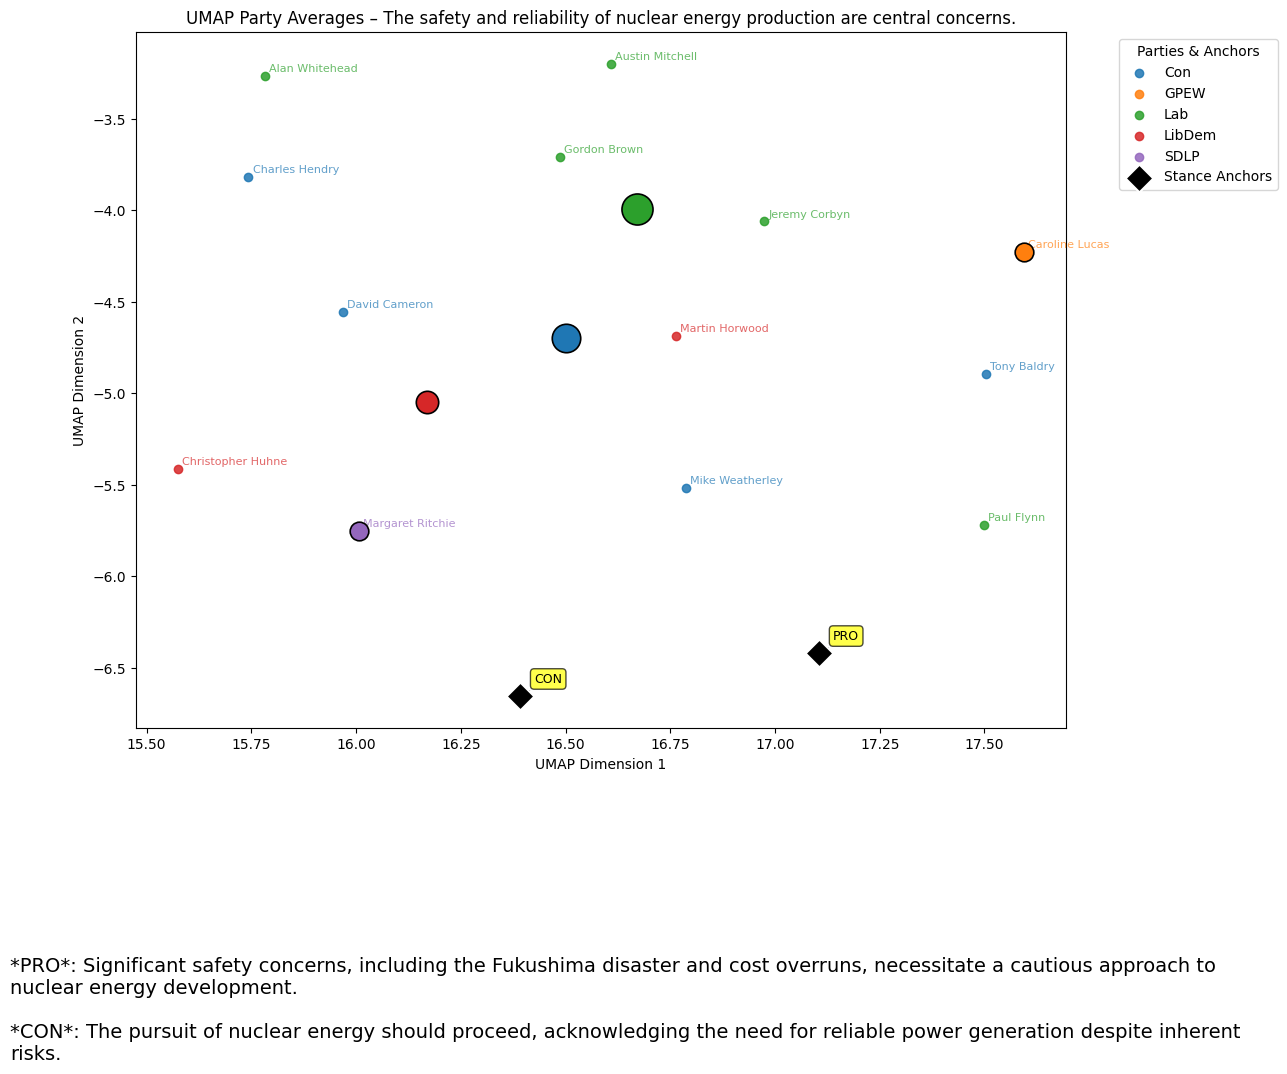

In [46]:
embeddings = uk.compute_umap_embeddings('nuclear', anchors[0])
uk.plot_umap_party_averages(embeddings, 'nuclear')

In [47]:
politician_stance(summarizations=summarizations, name="Paul Flynn")

'The politician believes nuclear energy should not be pursued due to significant cost overruns, safety concerns highlighted by the Fukushima disaster, and declining public confidence, particularly given other countries’ abandonment of nuclear plans.'

In [31]:
politician_stance(summarizations=summarizations, name="Christopher Huhne")

'The politician believes nuclear energy should be part of the UK’s energy mix, but opposes government funding and recognises the need to maintain reliable power generation.'

In [32]:
politician_stance(summarizations=summarizations, name="Martin Horwood")

'The politician opposes the development of new nuclear power stations due to concerns about safety, cost, waste disposal, and lack of international standards.'

Computing UMAP embeddings for topic: nuclear


Batches: 100%|██████████| 1/1 [00:02<00:00,  2.38s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


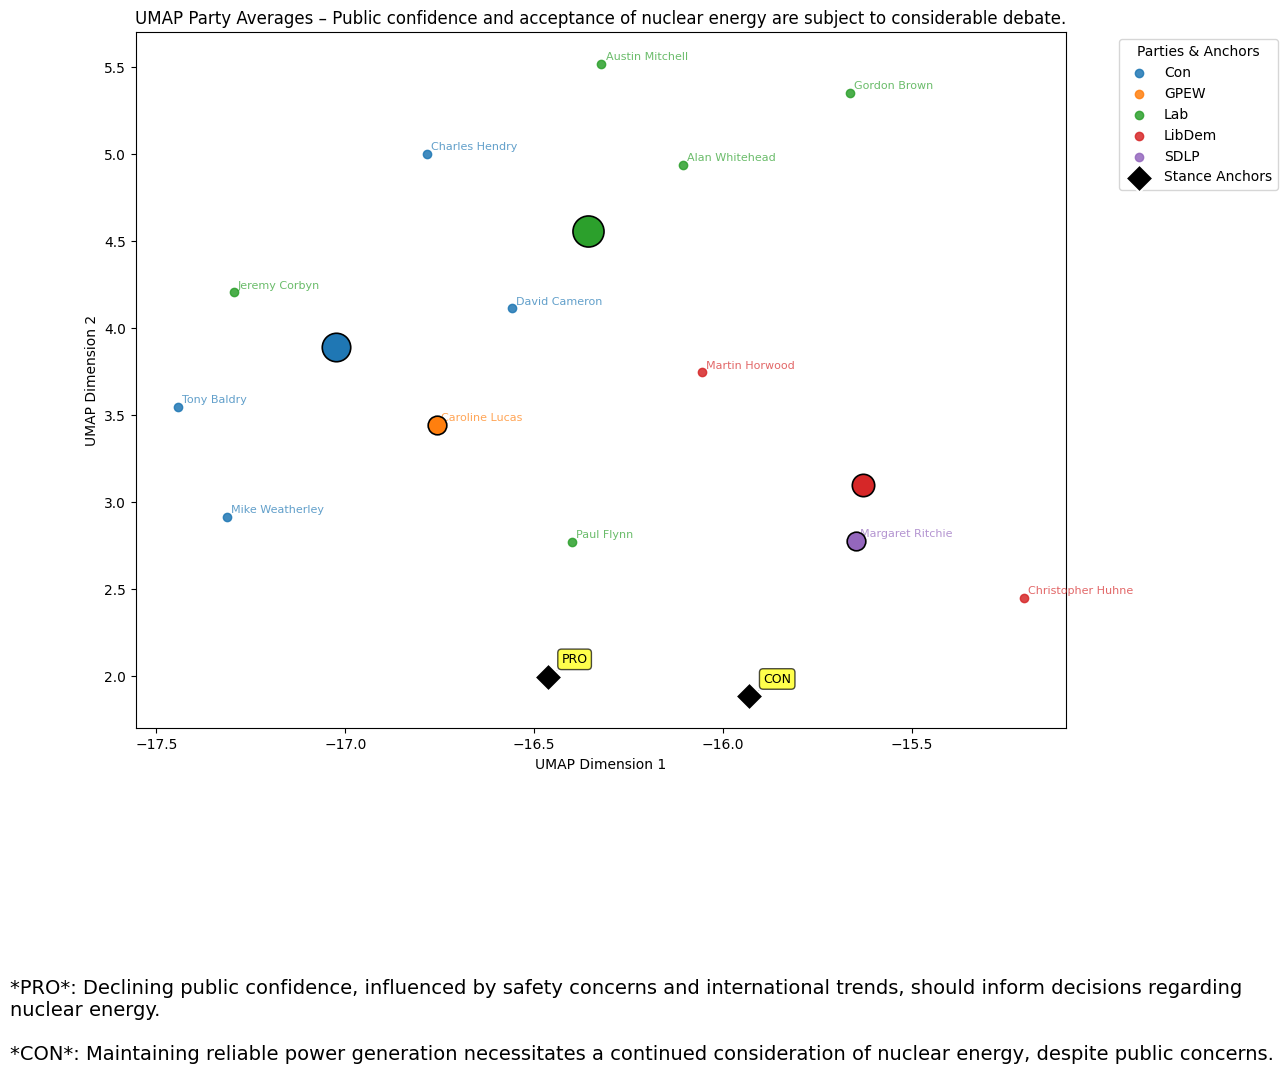

In [49]:
embeddings = uk.compute_umap_embeddings('nuclear', anchors[2])
uk.plot_umap_party_averages(embeddings, 'nuclear')

In [55]:
politician_stance(summarizations=summarizations, name="Christopher Huhne")


'The politician believes nuclear energy should be part of the UK’s energy mix, but opposes government funding and recognises the need to maintain reliable power generation.'

## Gaza

In [7]:
topic='Gaza'


In [ ]:

filtered_df= uk.filter_speeches(topic, years=[2011, 2012, 2013, 2014])
classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

In [8]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')

# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)

In [9]:
anchors=uk.generate_anchors(topic)

Generating stance anchors for topic: Gaza


In [10]:
anchors

[{'topic': 'The legitimacy of Hamas as a negotiating partner.',
  'pro': 'Hamas’s continued rejection of Israel’s existence, support for violence, and reliance on external actors like Iran fundamentally undermine any possibility of a genuine peace process and necessitate a complete rejection of engagement.',
  'con': 'Hamas’s position is a consequence of the broader conflict and its rejection of engagement is a tactical response to the ongoing situation, requiring a nuanced approach to negotiations.'},
 {'topic': 'The role of Israeli settlements in achieving a two-state solution.',
  'pro': 'The expansion of Israeli settlements directly undermines the feasibility of a two-state solution by encroaching on land designated for a Palestinian state and exacerbating tensions.',
  'con': 'Settlement expansion, while a contentious issue, is a response to legitimate security concerns and does not inherently preclude a negotiated resolution.'},
 {'topic': 'The humanitarian situation in Gaza and 

Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:06<00:00,  3.17s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


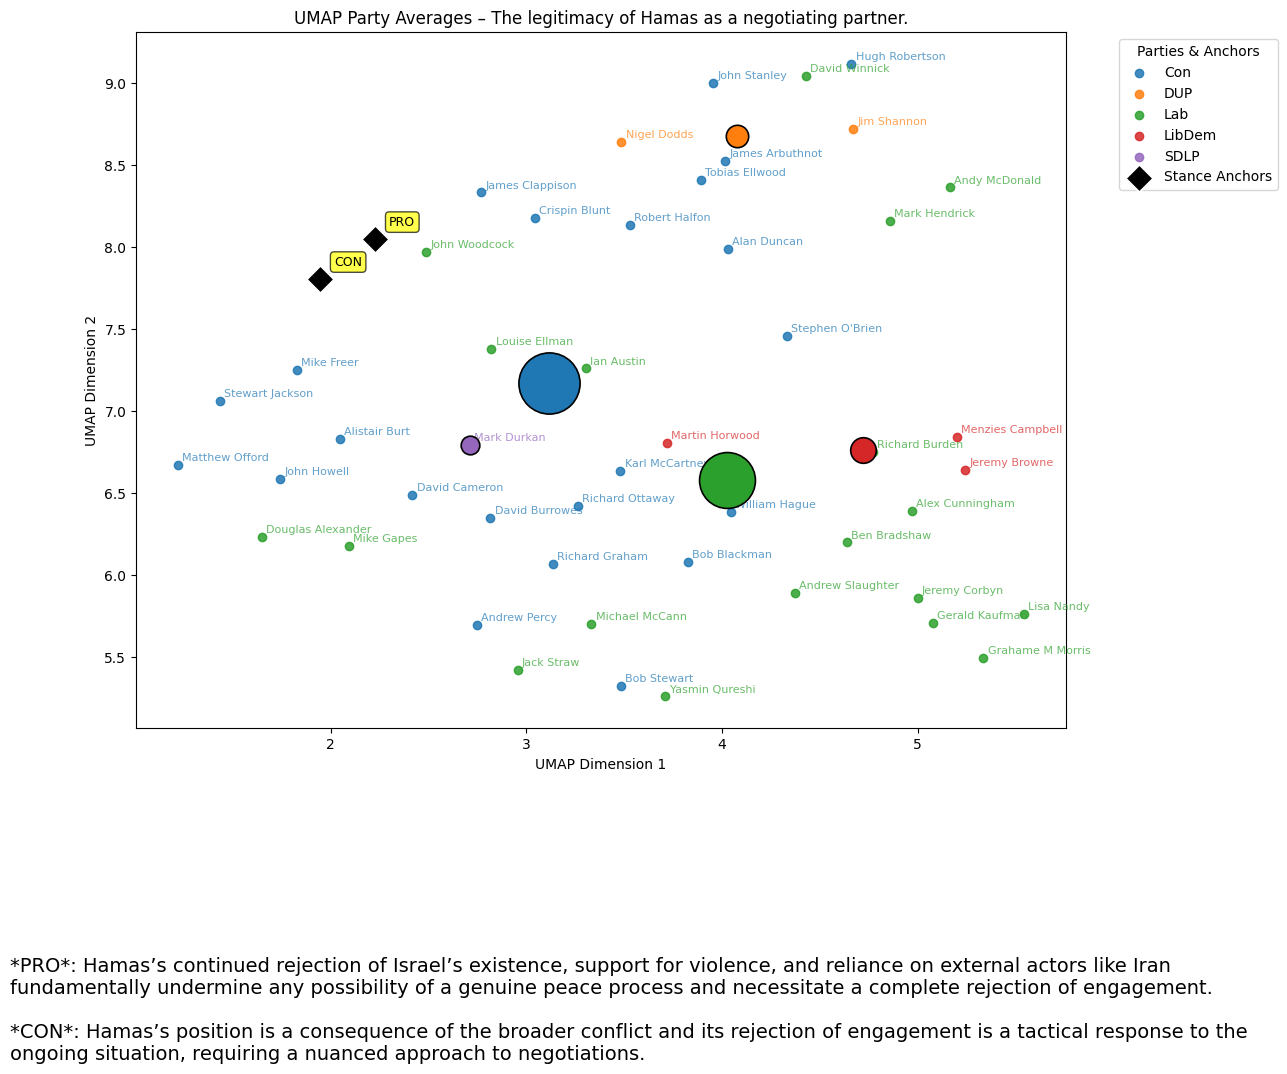

In [11]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:06<00:00,  3.25s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


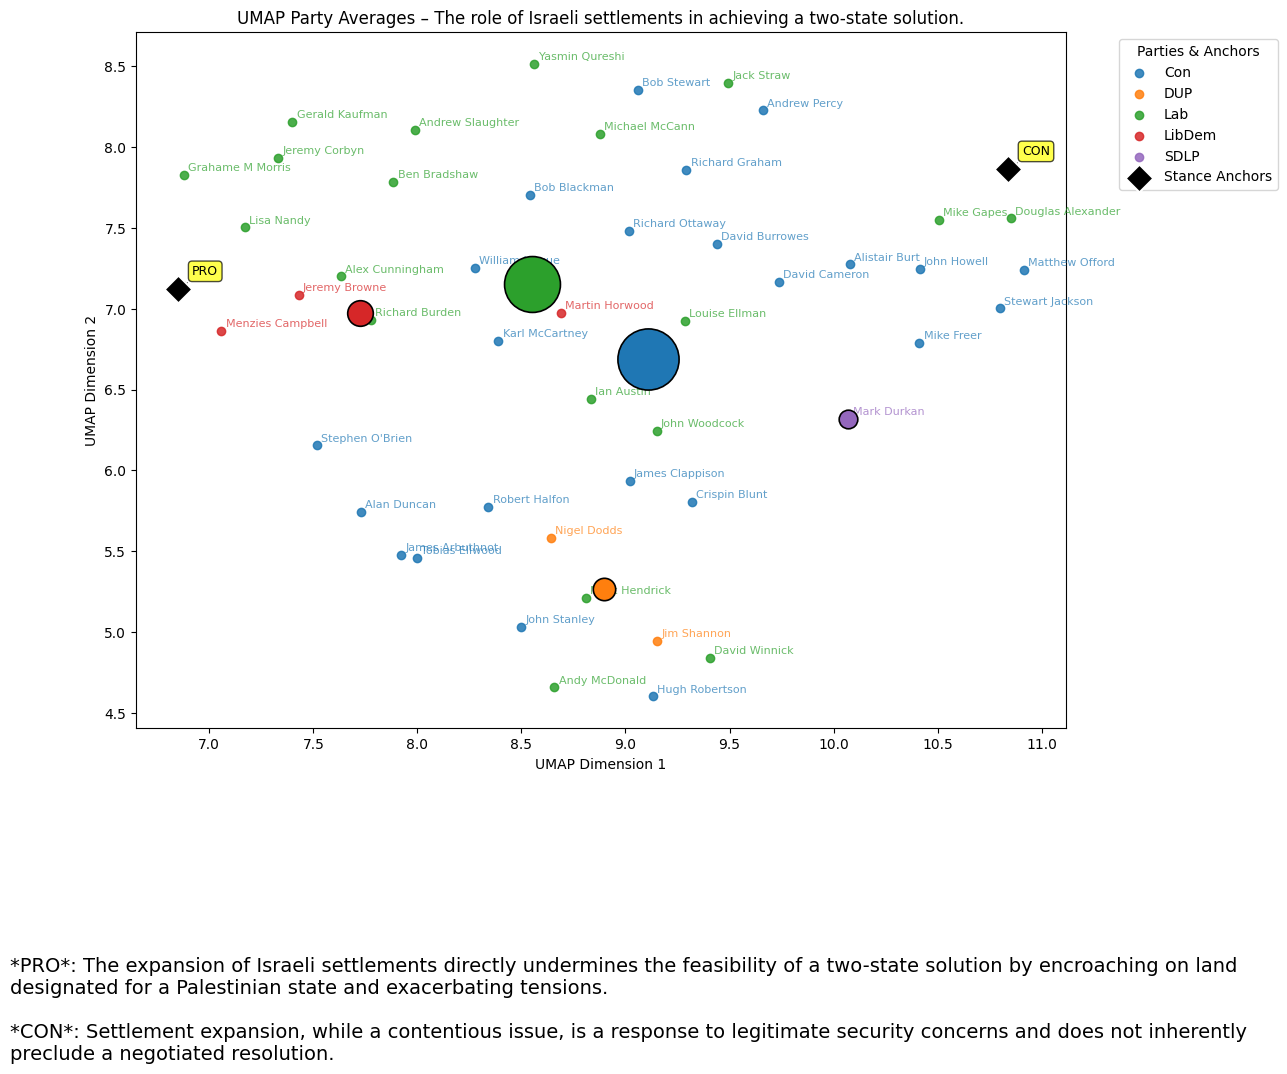

In [12]:
embeddings = uk.compute_umap_embeddings(topic, anchors[1])
uk.plot_umap_party_averages(embeddings, topic)

In [16]:
politician_stance(summarizations=summarizations, name="Lisa Nandy")

'The Secretary of State expresses concern over civilian casualties in Gaza and the West Bank, advocating for Palestinian participation in negotiations and state recognition.'

Computing UMAP embeddings for topic: Gaza


Batches: 100%|██████████| 2/2 [00:07<00:00,  3.68s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


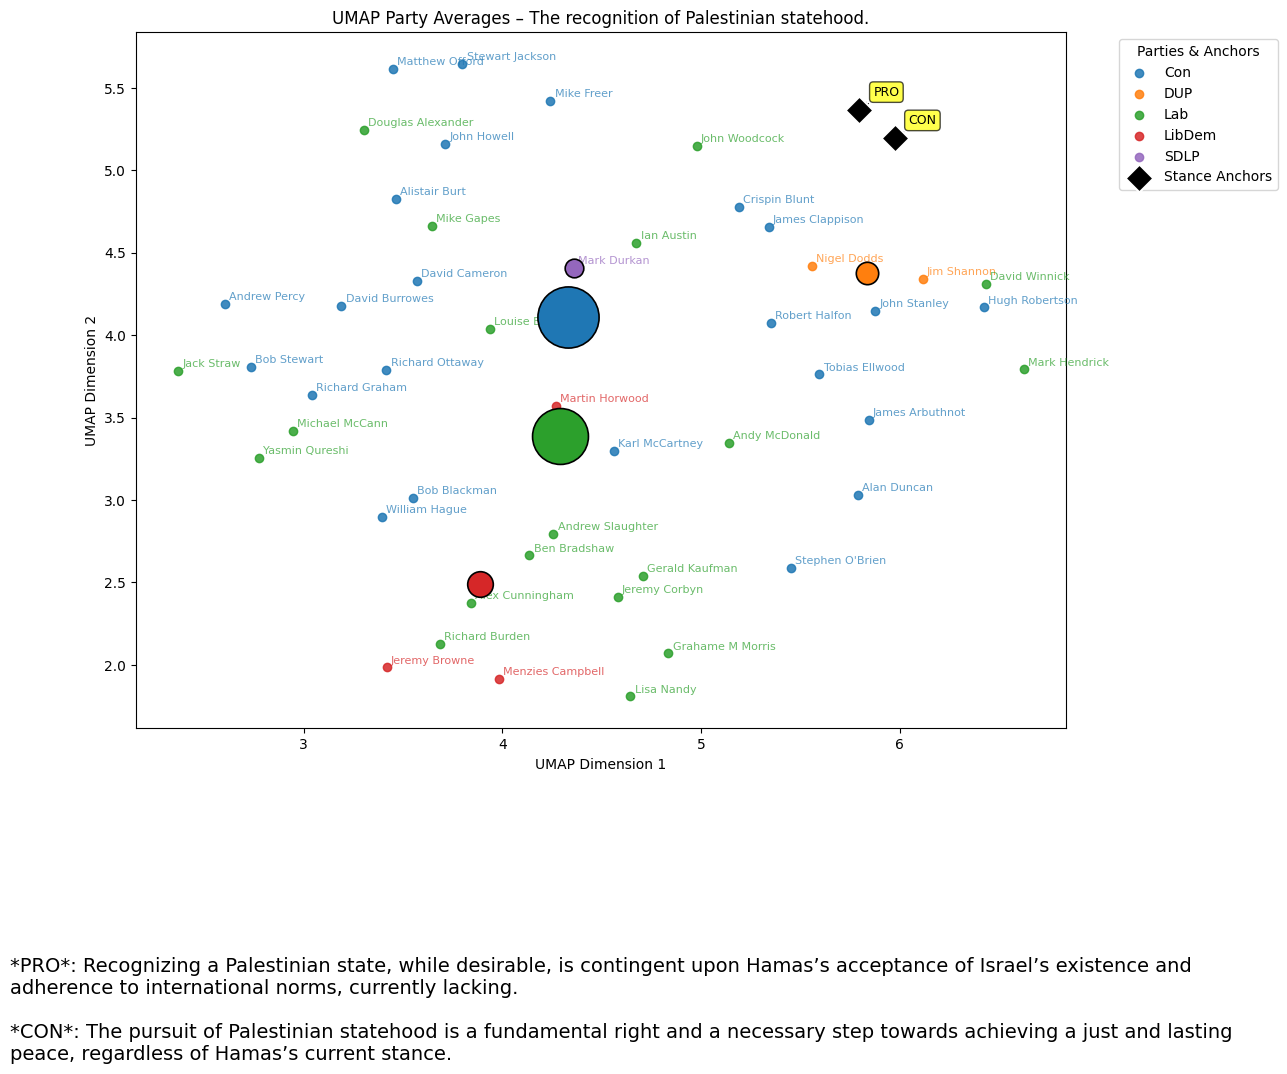

In [13]:
embeddings = uk.compute_umap_embeddings(topic, anchors[3])
uk.plot_umap_party_averages(embeddings, topic)

In [14]:
politician_stance(summarizations=summarizations, name="Nigel Dodds")

'The politician believes Hamas and Hezbollah aim to destroy Israel and the Jewish people, and questions whether recognizing a Palestinian state would deter this.'

In [25]:
politician_stance(summarizations=summarizations, name="Tobias Ellwood")

'The politician advocates for a decisive change away from Hamas, expressing concern about the potential for a more extreme group to take its place.'

## Climate change

In [17]:
topic='climate change'

In [30]:
filtered_df= uk.filter_speeches(topic, years=[2011, 2012, 2013, 2014])

classified_df = uk.classify_filtered_sentences(topic)
summarizations=uk.summarize_all_sentences(topic)

# DEBUG: save summarizations dataframe to csv file
summarizations.to_csv(f'./../data/processed/summarizations_{topic}.csv', index=False)

Filtering speeches for topic: climate change
Number of speeches after filtering for topic 'climate change' in years [2011, 2012, 2013, 2014]: 1265
Classifying filtered speeches for topic: climate change
"Number of opinionated speeches for climate change: 125
Summarization completed for topic: climate change


In [18]:
# DEBUG: read generated summaries from csv file ----------
summarizations = pd.read_csv(f'./../data/processed/summarizations_{topic}.csv')
# Useful for testing purposes, no need to resummarize every time
uk.set_summarization_for_topic(topic, summarizations)   

In [19]:
anchors=uk.generate_anchors(topic)

Generating stance anchors for topic: climate change


In [22]:
anchors

[{'topic': 'The prioritization of economic growth and energy costs versus ambitious climate targets.',
  'pro': 'Rapid adoption of renewable energy sources is necessary to achieve emissions reduction targets and ensure long-term energy security.',
  'con': 'Prioritizing economic growth and stable energy costs over aggressive climate action is essential to maintain competitiveness and avoid harming consumers.'},
 {'topic': 'The role of government intervention versus private sector involvement in renewable energy development.',
  'pro': 'Government support, including investment and incentives, is crucial to stimulate growth and overcome market limitations in the renewable energy sector.',
  'con': 'Private sector involvement and existing building solutions are more effective and economically viable than government-backed renewable energy schemes.'},
 {'topic': 'The appropriate scale and type of renewable energy investment.',
  'pro': 'Expanding renewable energy infrastructure, particular

Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:04<00:00,  2.20s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


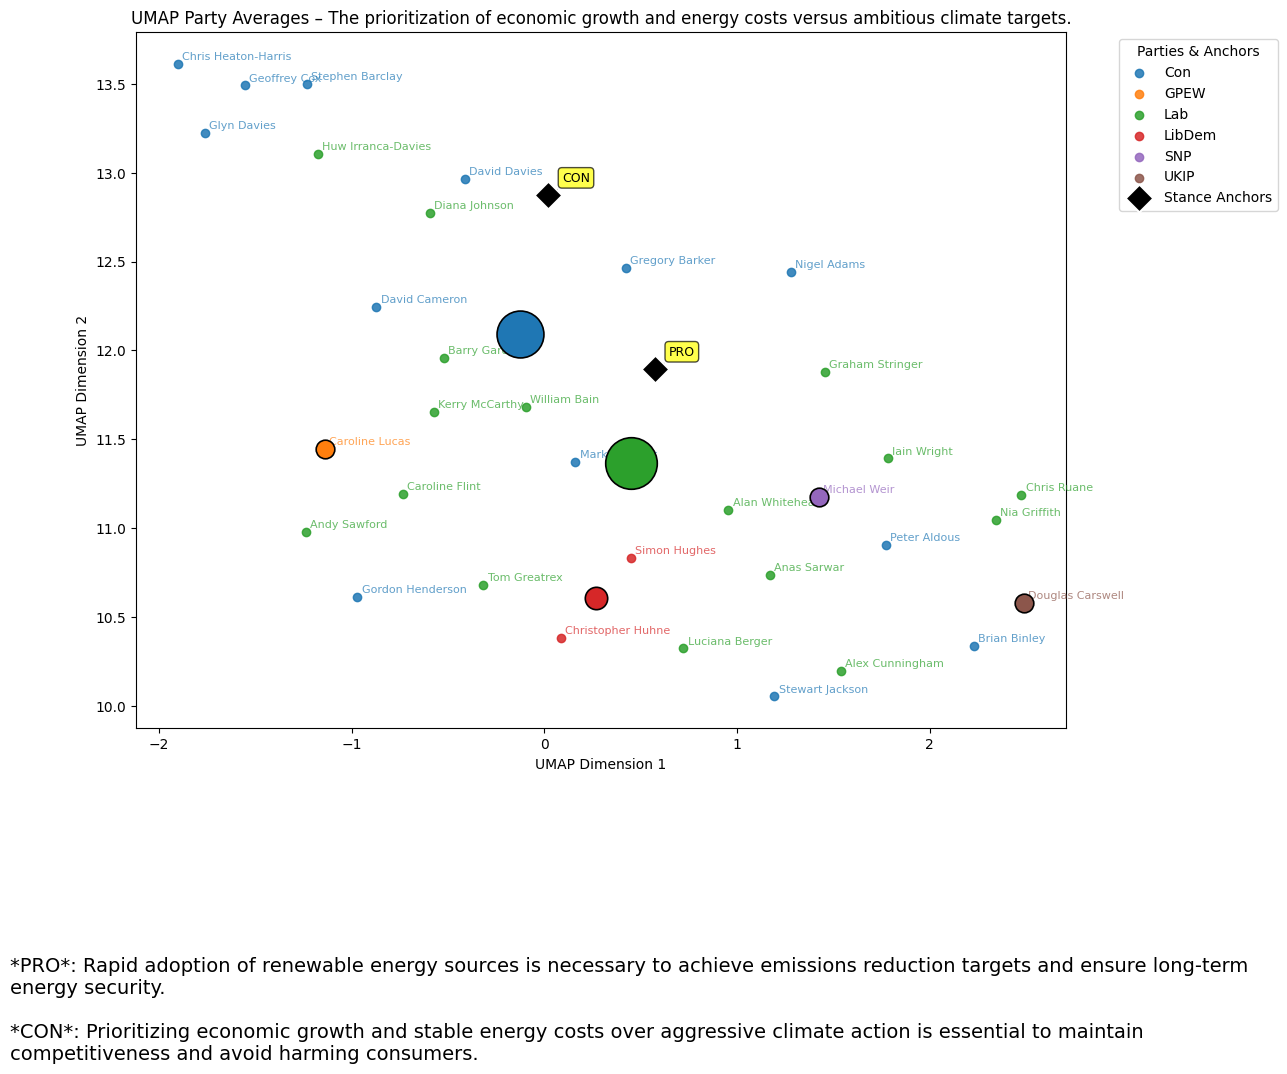

In [23]:
embeddings = uk.compute_umap_embeddings(topic, anchors[0])
uk.plot_umap_party_averages(embeddings, topic)

In [35]:
politician_stance(summarizations=summarizations, name="David Cameron")

'The politician opposes ambitious, internationally mandated targets for reducing carbon emissions, prioritizing economic growth and consumer energy costs over rapid adoption of renewable energy.'

In [36]:
politician_stance(summarizations=summarizations, name="Diana Johnson")

'The politician supports prioritizing business growth and local council autonomy over government-led climate initiatives.'

In [37]:
politician_stance(summarizations=summarizations, name="William Bain")

'The politician believes urgent and long-term action is needed to achieve emissions reduction targets and support investment in renewable energy.'

In [38]:
politician_stance(summarizations=summarizations, name="Douglas Carswell")

'The politician believes that government support for renewable energy is making European economies less competitive and unsustainable.'

Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:04<00:00,  2.08s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


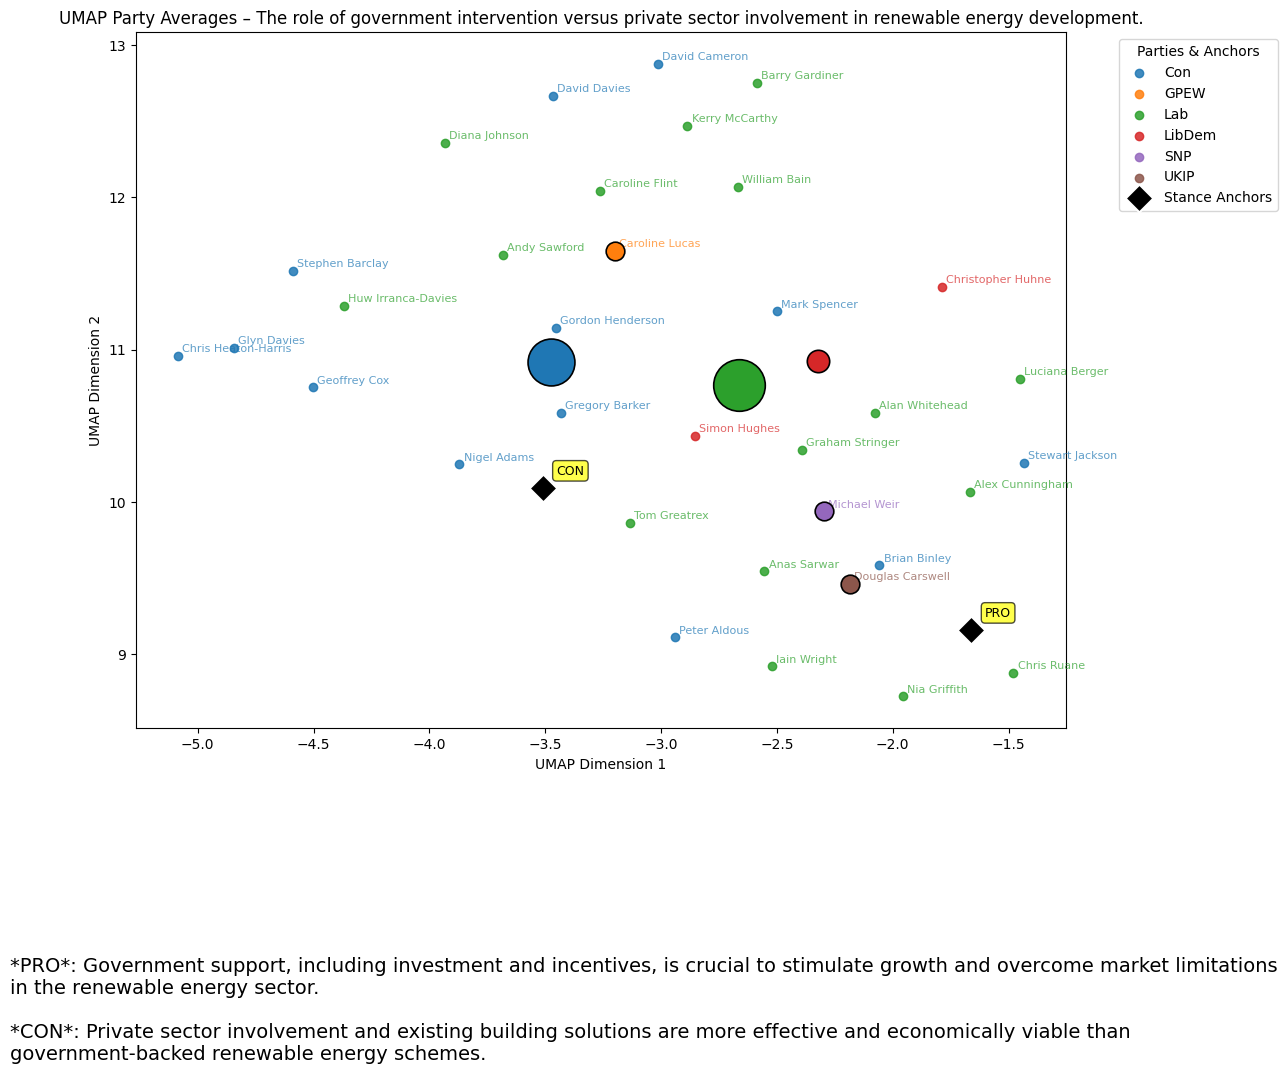

In [24]:
embeddings = uk.compute_umap_embeddings(topic, anchors[1])
uk.plot_umap_party_averages(embeddings, topic)

Computing UMAP embeddings for topic: climate change


Batches: 100%|██████████| 2/2 [00:04<00:00,  2.07s/it]
c:\Users\FedeF\Documents\GitHub\stance-detection-eu-parliaments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


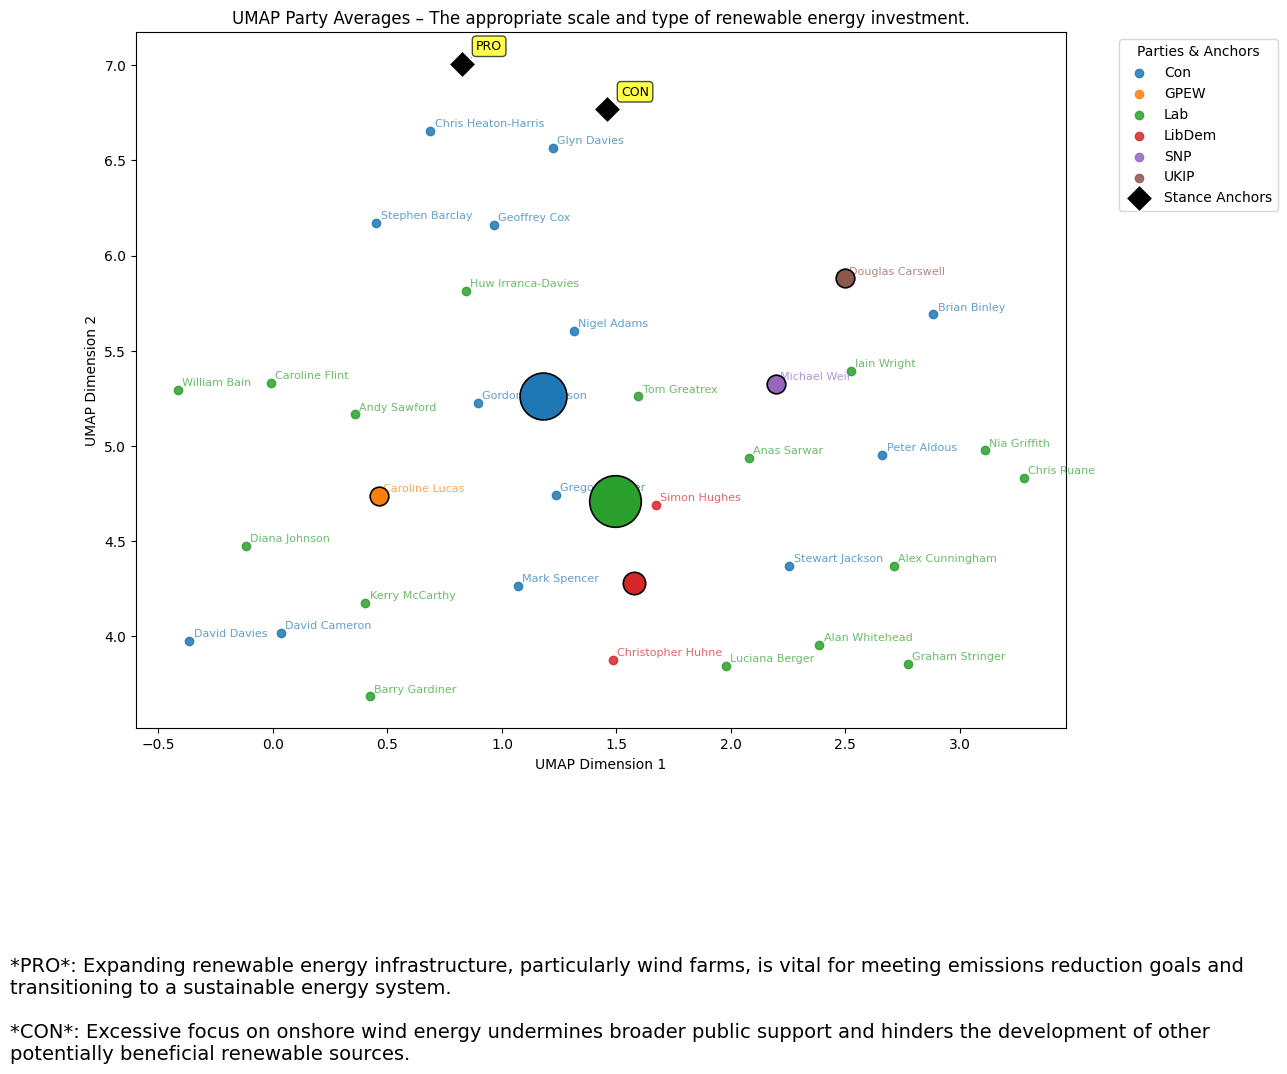

In [25]:
embeddings = uk.compute_umap_embeddings(topic, anchors[2])
uk.plot_umap_party_averages(embeddings, topic)

## Building the axis of controversy

In [32]:
topic = "climate change"
speaker_embeddings, anchor_embeddings = uk.compute_embeddings(topic, anchors[0])

Computing embeddings for topic: climate change
['The politician favors a greater reliance on onshore wind and biofuels while opposing devolved decision-making regarding energy policy.', 'The politician opposes the expansion of onshore wind farms and prioritizes preserving the landscape.', 'The politician supports the expansion of renewable energy infrastructure, particularly wind farms, while expressing concern about the potential negative impacts on landowners and the rising cost of energy for consumers.', 'The politician supports prioritizing business growth and local council autonomy over government-led climate initiatives.', 'He believes the Conservative-Liberal Democrat government’s actions have hindered investment in renewable energy, negatively impacting the UK’s position in green technology.', 'The politician believes the government’s approach to renewable energy is failing, hindering progress, and damaging the UK’s ability to meet its environmental targets.', 'The politician e

Batches: 100%|██████████| 2/2 [00:04<00:00,  2.14s/it]


In [31]:
speaker_embeddings.shape, anchor_embeddings.shape

((48, 1024), (2, 1024))